In [63]:
# PCA : 주성분분석(데이터의 핵심 특징만 남기고 차원은 줄인다)
# 분산이 가장 큰 방향 찾는다(데이터가 가장 넓게 퍼져있는 방향) -> 정보가 많다
# 1주성분(PC1)/2주성분(PC2): PC1과 직교하는 방향

# 변수가 10개 (국어, 수학, 영어, 체육, 과학, 사회 ...)
# 수학 영어

In [64]:
import numpy as np # 수치계산/ 배열. 연산
import pandas as pd # 데이터 처리/분석
import matplotlib.pyplot as plt # 데이터 시각화
from sklearn.preprocessing import StandardScaler # 정규화 스케일링
from sklearn.model_selection import train_test_split # 학습용과 테스트용으로 나누는 함수
from sklearn.linear_model import LogisticRegression # 로지스틱 회귀모델
from sklearn.metrics import accuracy_score # 예측값, 실제값 비교해서 정확도 계산하는 함수

In [65]:
churn_df=pd.read_csv("c:/a/run/ChurnData.csv")
churn_df

,tenure,age,address,income,ed,employ,equip,callcard,wireless,longmon,tollmon,equipmon,cardmon,wiremon,longten,tollten,cardten,voice,pager,internet,callwait,confer,ebill,loglong,logtoll,lninc,custcat,churn
0,11.0,33.0,7.0,136.0,5.0,5.0,0.0,1.0,1.0,4.40,20.75,0.00,15.25,35.7,42.00,211.45,125.0,1.0,1.0,0.0,1.0,1.0,0.0,1.482,3.033,4.913,4.0,1.0
1,33.0,33.0,12.0,33.0,2.0,0.0,0.0,0.0,0.0,9.45,0.00,0.00,0.00,0.0,288.80,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.246,3.240,3.497,1.0,1.0
2,23.0,30.0,9.0,30.0,1.0,2.0,0.0,0.0,0.0,6.30,0.00,0.00,0.00,0.0,157.05,0.00,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.841,3.240,3.401,3.0,0.0
3,38.0,35.0,5.0,76.0,2.0,10.0,1.0,1.0,1.0,6.05,45.00,50.10,23.25,64.9,239.55,1873.05,880.0,1.0,1.0,1.0,1.0,1.0,1.0,1.800,3.807,4.331,4.0,0.0
4,7.0,35.0,14.0,80.0,2.0,15.0,0.0,1.0,0.0,7.10,22.00,0.00,23.75,0.0,47.45,166.10,145.0,1.0,0.0,0.0,1.0,1.0,0.0,1.960,3.091,4.382,3.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,55.0,44.0,24.0,83.0,1.0,23.0,0.0,1.0,0.0,17.35,24.50,0.00,14.25,0.0,973.10,1343.50,720.0,0.0,0.0,0.0,0.0,1.0,0.0,2.854,3.199,4.419,3.0,0.0
196,34.0,23.0,3.0,24.0,1.0,7.0,0.0,1.0,0.0,6.00,28.00,0.00,12.75,0.0,203.25,959.40,435.0,0.0,0.0,0.0,1.0,1.0,0.0,1.792,3.332,3.178,3.0,0.0
197,6.0,32.0,10.0,47.0,1.0,10.0,0.0,1.0,0.0,3.85,23.75,0.00,12.50,0.0,29.90,128.45,80.0,0.0,0.0,0.0,1.0,1.0,0.0,1.348,3.168,3.850,3.0,0.0
198,24.0,30.0,0.0,25.0,4.0,5.0,0.0,1.0,1.0,8.70,47.75,0.00,32.75,64.0,186.60,1152.90,780.0,1.0,1.0,1.0,1.0,1.0,1.0,2.163,3.866,3.219,4.0,1.0


In [66]:
# churn 제외
columns=churn_df.columns[:-1]

# 마지막 컬럼 제외하고 피처줌
features=churn_df.loc[:,columns]
# 정답(목표변수) (모델이 예측할 값)
label=churn_df['churn']

In [67]:
# 20프로만 테스트용
X_train, X_test, y_train, y_test=train_test_split(features, label,test_size=0.2, random_state=1)

In [68]:
#표준화 시키기
sc=StandardScaler()
X_train=sc.fit_transform(X_train)
X_test=sc.transform(X_test)

In [69]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((160, 27), (40, 27), (160,), (40,))

In [70]:
lr=LogisticRegression(solver='lbfgs',random_state=1)
# 학습데이터의 문제와 정답을 주고 학습시킨다.
# y=wx+b
lr.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multic

In [71]:
# 예측, 정확도
# 테스트용 문제를 주며 정답을 예측한다
y_pred=lr.predict(X_test)
# 실제값과 모델이 예측한 값을 비교해 정확도 출력
# 100개 샘플 중 82개 맞춤
accuracy_score(y_test, y_pred)

0.825

In [72]:
# PCA 적용
from sklearn.decomposition import PCA
# 2차원
pca=PCA(n_components=2)

In [73]:
# 어느 방향으로 가장 넓게 퍼져있는지 찾아냄(주성분축)-> 찾아낸 축 기준으로 학습 데이터를 2차원으로 변환
X_train_pca=pca.fit_transform(X_train)
# 테스트 데이터는 새로운 축 찾는데 관여하지 않음(학습데이터에서 찾았던 축 그대로 사용)
X_test_pca=pca.transform(X_test)

In [74]:
X_train_pca.shape, X_test_pca.shape

((160, 2), (40, 2))

In [75]:
# 주성분 크기
# 원본데이터 27차원/ pca로 2차원으로 축소시킴
print(pca.components_[0]) #pc1 -> 가장 많은 분산을 설명하는 방향의 벡터값
print(pca.components_[1]) #pc2 -> pc1에 직교하면서 두번째로 많은 분산을 설명하는 방향의 벡터값

[0.22868251 0.14591258 0.10393308 0.05228089 0.03940592 0.16455981
 0.04773625 0.22721116 0.21080861 0.20312999 0.26000934 0.11785771
 0.25597858 0.25325173 0.20559347 0.28029559 0.2426773  0.20781866
 0.23437339 0.02717868 0.21531435 0.20054001 0.03148224 0.21684582
 0.18617202 0.12441312 0.26489625]
[ 0.24256672  0.20454345  0.23485898  0.03972271 -0.1679365   0.20451427
 -0.20965314  0.08615314 -0.25912194  0.27180971 -0.14444607 -0.23506371
  0.13265303 -0.23935328  0.27511454 -0.05795038  0.20371649 -0.21787441
 -0.19855337 -0.22867159 -0.13434126 -0.12062796 -0.18349733  0.25681055
 -0.04266005  0.06949854 -0.17478113]


In [76]:
#(n_components 설정값, n_features 원본특성개수)
pca.components_.shape

(2, 27)

In [77]:
print(pca.explained_variance_ratio_, sum(pca.explained_variance_ratio_))

[0.26111008 0.22214236] 0.48325243781542393


In [78]:
lr=LogisticRegression(solver='lbfgs', random_state=1)
# pca로 축소시킨 학습데이터의 문제와 정답을 주고 학습시킨다.
lr.fit(X_train_pca, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multic

In [79]:
y_pred=lr.predict(X_test_pca)
accuracy_score(y_test,y_pred)

0.775

In [81]:
# pca로 변환된 학습데이터 중, y_train이 0이 데이터만 선택함
X_train_pca[y_train==0]

array([[-1.88271112e+00,  8.88278708e-01],
       [ 3.39252323e-01,  1.50712204e+00],
       [-3.50671382e+00,  2.33779886e-01],
       [-3.63457798e-01, -1.80562517e+00],
       [-3.39314298e+00, -7.75789315e-01],
       [ 4.22819135e+00, -3.39247568e+00],
       [ 2.19846279e+00, -3.18315805e+00],
       [-6.83381247e-01,  2.79016465e+00],
       [ 9.64824361e-02,  3.24127500e+00],
       [-2.72916250e+00,  1.66988564e+00],
       [-1.22924794e+00,  4.01073098e-01],
       [ 3.20223035e+00,  5.57384515e-01],
       [ 5.00152593e+00,  6.35447209e+00],
       [-1.42174474e+00, -5.78214016e-01],
       [ 1.80135579e+00,  8.10825493e-01],
       [ 2.28610715e+00,  4.59017115e+00],
       [ 3.19712285e-01,  3.67315897e+00],
       [ 1.17261818e+00,  4.48979916e+00],
       [ 6.33927519e+00, -1.60226139e+00],
       [ 1.01685000e+00, -1.80667922e+00],
       [ 2.18364561e-01,  4.33309129e+00],
       [ 2.88517881e+00, -4.70492006e+00],
       [ 4.18833607e+00,  2.14879586e+00],
       [-1.

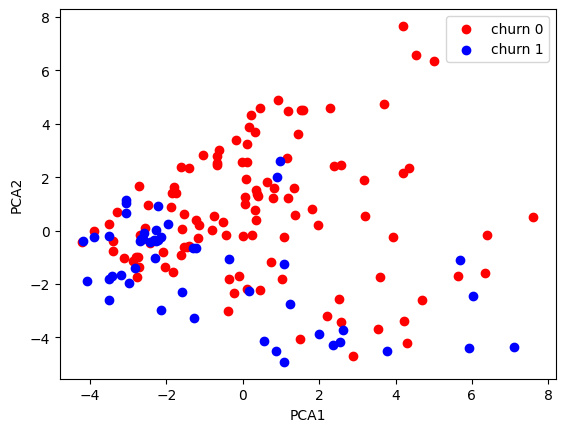

In [86]:
# y_train=0일때 첫번째 pca, 두번째 pca 값 가져옴
X1,X2=X_train_pca[y_train==0,0], X_train_pca[y_train==0,1]
plt.scatter(X1,X2,color='r', label='churn 0')

# y_train==1(고객이탈함) 일 때 첫번째 특징(pc1 - x축), 두번째 특정(pc2 - y축)
X1,X2=X_train_pca[y_train==1,0], X_train_pca[y_train==1,1]
plt.scatter(X1,X2,color='b', label='churn 1')

# 첫번째 특징 - pc1 (데이터 정보를 가장 많이 담고있다)
# 두번째 특징 - pc2 (그 안에서 놓친 정보를 보완한다)

plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.legend()

In [ ]:
# 주성분의미 : pca1축에서 데이터가 길게 펼쳐져 있다.(첫번째 주성분이 이탈고객 여부 특성을 잘 설명함)
